In [17]:
# import plotting libraries
import matplotlib.pyplot as plt

from matplotlib import style

import seaborn as sns
sns.set(style="white", color_codes=True)
sns.set(font_scale=1.5)

from gensim.models import Word2Vec

In [18]:
# define training data
# sentences = [
#     ['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
# 	['this', 'is', 'the', 'second', 'sentence'],
# 	['yet', 'third', 'sentence'],
# 	['one', 'fourth', 'sentence'],
# 	['and', 'the', 'fifth', 'sentence']]

In [19]:
# define training data
sentences = [
    ['data', 'science', 'Machine', 'AI', 'learning', 'analytics', 'word2vec'],
    ['Machine', 'AI', 'learning','Machine', 'AI', 'learning','Machine', 'AI', 'learning'],
	['soccer', 'rugby', 'playing', 'soccer field', 'big'],
	['yet', 'third', 'sentence'],
	['one', 'fourth', 'sentence'],
	['and', 'the', 'fifth', 'sentence']]

In [20]:
# train model
model = Word2Vec(sentences=sentences, vector_size=2, min_count=1)

In [21]:
# summarize the loaded model
print(model)

Word2Vec<vocab=20, vector_size=2, alpha=0.025>


In [22]:
# Get the list of words in the vocabulary
words_in_vocab = model.wv.index_to_key
words_in_vocab

['Machine',
 'AI',
 'learning',
 'sentence',
 'fifth',
 'rugby',
 'science',
 'analytics',
 'word2vec',
 'soccer',
 'playing',
 'the',
 'soccer field',
 'big',
 'yet',
 'third',
 'one',
 'fourth',
 'and',
 'data']

In [23]:
# Get the frequency of a specific word
word = "learning"
frequency = model.wv.get_vecattr(word, "count")
frequency

4

In [24]:
# Get the vector for a specific word
vector = model.wv.get_vector(word)
vector

array([-0.4651475 , -0.35584044], dtype=float32)

In [25]:
model.wv[word]

array([-0.4651475 , -0.35584044], dtype=float32)

In [26]:
from scipy.spatial import distance

In [27]:
cosine_sim = 1 - distance.cosine(model.wv['data'], model.wv['science'])
cosine_sim

-0.8276093215518707

A cosine similarity value of -0.8276093006134033 indicates that the two vectors being compared are somewhat dissimilar and have an angle of approximately 135 degrees between them in the vector space. 

In [28]:
import numpy as np

In [29]:
# method - 2 - using numpy
# manually compute cosine similarity
dot = np.dot(model.wv['data'], model.wv['science'])
norma = np.linalg.norm(model.wv['data'])
normb = np.linalg.norm(model.wv['science'])
cos = dot / (norma * normb)

print("Cosine similarity is {}".format(cos))
print("Cosine distance   is {}".format(1-cos))

Cosine similarity is -0.8276093006134033
Cosine distance   is 1.8276093006134033


In [30]:
# save model
model.save('model.bin')

In [31]:
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

Word2Vec<vocab=20, vector_size=2, alpha=0.025>


In [32]:
# Get all word vectors
all_vectors = model.wv.vectors
all_vectors

array([[-0.02681136,  0.01182157],
       [ 0.25516748,  0.45046365],
       [-0.4651475 , -0.35584044],
       [ 0.32294363,  0.4486494 ],
       [-0.2507714 , -0.18816859],
       [ 0.36928058, -0.07674848],
       [-0.22683066,  0.32770258],
       [-0.24300802, -0.09080088],
       [ 0.14382899,  0.04959369],
       [-0.4141709 , -0.47247273],
       [ 0.3655883 ,  0.2535131 ],
       [ 0.33788466,  0.03814328],
       [ 0.31759265, -0.1702941 ],
       [-0.0472302 ,  0.28839684],
       [-0.37608188, -0.19680518],
       [-0.37557912, -0.04650211],
       [ 0.47690594, -0.36595833],
       [-0.11668843, -0.09688705],
       [ 0.40387183, -0.2965448 ],
       [ 0.00225812, -0.2376867 ]], dtype=float32)

#### Plot Word Vectors Using PCA

In [55]:
from sklearn.decomposition import PCA
from matplotlib import pyplot
%matplotlib inline

In [56]:
pca    = PCA(n_components=2)
result = pca.fit_transform(all_vectors)

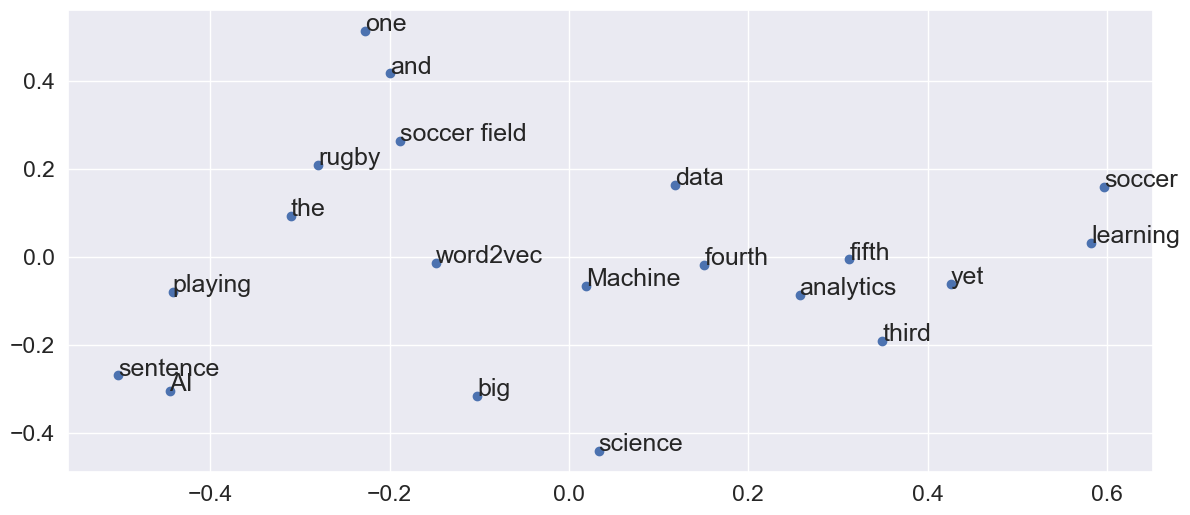

In [57]:
plt.figure(figsize=(14, 6))
plt.scatter(result[:, 0], result[:, 1])

# Get the list of words in the vocabulary
words = model.wv.index_to_key


for i, word in enumerate(words):
	pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))

#### Example 2

#### Load Google’s Word2Vec Embedding
- Training your own word vectors may be the best approach for a given NLP problem.

- But it can take a long time, a fast computer with a lot of RAM and disk space, and perhaps some expertise in finessing the input data and training algorithm.

- An alternative is to simply use an existing `pre-trained word embedding`.

- A pre-trained model is nothing more than a file containing tokens and their associated word vectors. 

- The pre-trained Google `word2vec model` was trained on `Google news data` (about 100 billion words); it contains 3 million words and phrases and was fit using 300-dimensional word vectors.

It is a 1.53 Gigabytes file. You can download it from here: GoogleNews-vectors-negative300.bin.gz https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit



In [1]:
from gensim.models import KeyedVectors

In [34]:
# load the google word2vec model
filename = r'D:\AI-DATASETS\02-MISC-large\word2vec_Glove\GoogleNews-vectors-negative300.bin'

In [35]:
model    = KeyedVectors.load_word2vec_format(filename, 
                                             binary= True, 
                                             limit = 100000)

In [36]:
model.vector_size

300

In [37]:
# Get the vocabulary size
vocab_size = len(model.key_to_index)

print("Vocabulary size:", vocab_size)

Vocabulary size: 100000


#### Examples

calculate: (king - man) + woman = ?

In [38]:
result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=10)

result

[('queen', 0.7118192911148071),
 ('monarch', 0.6189674735069275),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.549946129322052),
 ('prince', 0.5377321243286133),
 ('kings', 0.5236843824386597),
 ('queens', 0.5181134343147278),
 ('sultan', 0.5098593235015869),
 ('monarchy', 0.5087411403656006),
 ('royal_palace', 0.5087166428565979)]

In [39]:
result = model.most_similar(positive=['India', 'Riyadh'], negative=['Bengaluru'], topn=4)

result

[('Saudi_Arabia', 0.7118990421295166),
 ('Saudi', 0.6528869271278381),
 ('Saudis', 0.5901263356208801),
 ('Saudi_Arabian', 0.5621386766433716)]

what if the token is not in the model

In [40]:
result = model.most_similar(positive=['India', 'London'], negative=['Delhi'], topn=4)

result

[('UK', 0.624866247177124),
 ('Britain', 0.607151985168457),
 ('Europe', 0.5445290207862854),
 ('Asia', 0.5214443206787109)]

In [41]:
result = model.most_similar(positive=['India', 'Karachi'], negative=['Bangalore'], topn=4)

result

[('Pakistan', 0.7550593614578247),
 ('Bangladesh', 0.6441816687583923),
 ('Balochistan', 0.623878538608551),
 ('Lahore', 0.6214929819107056)]

#### Example 3

In [43]:
pip install spacy

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached preshed-3.0.9-cp312-cp312-win_amd64.whl.metadata (2.2 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-0.4.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached typer-0.15.1-py3-none-any.whl.metadata (15 kB)
  Using cached langcodes-3.5.0-py3-none-any.whl.metadata (29 kB)
  Using cached language_data-1.3.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached confection-0.1.5-py3-none-any.whl.metadata (19 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached cloudpathlib-0.20.0-py3-none-any.whl.metadata (14 kB)
  Using cached marisa_trie-1.2.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
   ---------------------------------------- 0.0/11.8 MB ? eta -:--:--
   ---------------------------------------

In [44]:
import re  # For preprocessing
import pandas as pd  # For data handling

pd.set_option('display.max_colwidth', 120)

from time import time  # To time our operations
from collections import defaultdict  # For word frequency

import spacy  # For preprocessing

import logging  # Setting up the loggings to monitor gensim
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)

This dataset contains the characters, locations, episode details, and script lines for approximately 600 Simpsons episodes, dating back to 1989. It can be found here: https://www.kaggle.com/ambarish/fun-in-text-mining-with-simpsons/data (~25MB)

In [45]:
df = pd.read_csv(r'D:\AI-DATASETS\02-MISC-large\simpsons_dataset.csv')
df.shape

(158314, 2)

In [47]:
df.sample(5)

,raw_character_text,spoken_words
51291,Announcer,"And now... mid-season kicks off with ""Admiral Baby."""
52138,Homer Simpson,NaN
2555,Luann Van Houten,"Marge, I'm sorry, but I think it would be better if Milhouse didn't see your son."
23809,Moe Szyslak,"Maybe... but maybe, we don't want to be Stonecutters no more."
55522,Homer Simpson,"""Rough!"" Ah, I don't know. You've been pitching that all night."


In [48]:
df.isnull().sum()

raw_character_text    17814
spoken_words          26459
dtype: int64

In [49]:
# Removing the missing values:
df = df.dropna().reset_index(drop=True)
df.isnull().sum()

raw_character_text    0
spoken_words          0
dtype: int64

#### Cleaning:

We are lemmatizing and removing the stopwords and non-alphabetic characters for each line of dialogue.

In [50]:
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser']) # disabling Named Entity Recognition for speed

In [51]:
def cleaning(doc):
    # Lemmatizes and removes stopwords
    # doc needs to be a spacy Doc object
    txt = [token.lemma_ for token in doc if not token.is_stop]
    
    # Word2Vec uses context words to learn the vector representation of a target word,
    # if a sentence is only one or two words long, the benefit for the training is very small
    
    if len(txt) > 2:
        return ' '.join(txt)

In [52]:
%%time

# Removes non-alphabetic characters:
brief_cleaning = (re.sub("[^A-Za-z']+", ' ', str(row)).lower() for row in df['spoken_words'])

CPU times: total: 0 ns
Wall time: 0 ns


#### Taking advantage of spaCy .pipe() 

In [53]:
%%time
## takes about 3 mins
t = time()

txt = [cleaning(doc) for doc in nlp.pipe(brief_cleaning, batch_size=5000)]

print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))

Time to clean up everything: 2.38 mins
CPU times: total: 1min 5s
Wall time: 2min 22s


In [54]:
# Put the results in a DataFrame to remove missing values and duplicates:
df_clean = pd.DataFrame({'clean': txt})
df_clean = df_clean.dropna().drop_duplicates()

df_clean.shape

(85952, 1)

In [55]:
df_clean.sample(10)

,clean
17635,surprised skip obviously smart
80500,prize wife swap
94922,oh bit rough
90122,lurleen daddy come thirty year father year leave thirty year
37228,ooo look perfect chance kid nice church shoe
69824,believe homer marge marriage sham right order um medium pepperoni space meat spell happy birthday moe oh god
96849,worry shark boy play possum leave
81704,admit feel little silly
112240,excuse brazilian record producer concentrate rapidly grow jug band samba fusion market
2365,reb krustofsky finish college


#### Bigrams:
We are using Gensim __Phrases__ package to automatically detect common phrases (bigrams) from a list of sentences.

In [56]:
from gensim.models.phrases import Phrases, Phraser

As Phrases() takes a list of list of words as input:

In [57]:
sent = [row.split() for row in df_clean['clean']]

In [58]:
phrases = Phrases(sent, min_count=30, progress_per=10000)

INFO - 11:13:59: collecting all words and their counts
INFO - 11:13:59: PROGRESS: at sentence #0, processed 0 words and 0 word types
INFO - 11:14:00: PROGRESS: at sentence #10000, processed 63557 words and 52712 word types
INFO - 11:14:00: PROGRESS: at sentence #20000, processed 130938 words and 99589 word types
INFO - 11:14:00: PROGRESS: at sentence #30000, processed 192957 words and 138115 word types
INFO - 11:14:00: PROGRESS: at sentence #40000, processed 249830 words and 172072 word types
INFO - 11:14:00: PROGRESS: at sentence #50000, processed 311271 words and 207879 word types
INFO - 11:14:00: PROGRESS: at sentence #60000, processed 373578 words and 242888 word types
INFO - 11:14:00: PROGRESS: at sentence #70000, processed 436426 words and 277777 word types
INFO - 11:14:00: PROGRESS: at sentence #80000, processed 497902 words and 310851 word types
INFO - 11:14:01: collected 329546 token types (unigram + bigrams) from a corpus of 537086 words and 85952 sentences
INFO - 11:14:01: m

Transform the corpus based on the bigrams detected:

In [60]:
sentences = phrases[sent]
sentences

#### Most Frequent Words:
Mainly a sanity check of the effectiveness of the lemmatization, removal of stopwords, and addition of bigrams.

In [61]:
word_freq = defaultdict(int)

for sent in sentences:
    for i in sent:
        word_freq[i] += 1
        
len(word_freq)

29685

In [63]:
sorted(word_freq, key=word_freq.get, reverse=False)[:10]

['leland',
 'promontory',
 'parkville',
 'mopey',
 'doover',
 'mixology',
 'planter',
 'cassis',
 'ssslurre',
 'shpeech']

In [62]:
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

['oh', 'like', 'know', 'get', 'hey', 'think', 'come', 'right', 'look', 'want']

#### Training the model
Gensim Word2Vec Implementation:

In [64]:
import multiprocessing

from gensim.models import Word2Vec

separate the training in 3 distinctive steps for clarity and monitoring.

1. Word2Vec():
In this first step, set up the parameters of the model one-by-one.
do not supply the parameter sentences, and therefore leave the model uninitialized, purposefully.

2. build_vocab():
Here it builds the vocabulary from a sequence of sentences and thus initialized the model.
With the loggings, we can follow the progress and even more important, the effect of __min_count__ and __sample__ on the word corpus. 

3. train():
Finally, trains the model.
The loggings here are mainly useful for monitoring, making sure that no threads are executed instantaneously.

In [65]:
cores = multiprocessing.cpu_count() # Count the number of cores in a computer
cores

4

#### The parameters:
- min_count = int - 

Ignores all words with total absolute frequency lower than this - (2, 100)

- window = int - 

The maximum distance between the current and predicted word within a sentence. E.g. window words on the left and window words on the left of our target - (2, 10)

- size = int - 

Dimensionality of the feature vectors. - (50, 300)

- sample = float - 

The threshold for configuring which higher-frequency words are randomly downsampled. Highly influencial. - (0, 1e-5)

- alpha = float - 

The initial learning rate - (0.01, 0.05)

- min_alpha = float - 

Learning rate will linearly drop to min_alpha as training progresses. To set it: alpha - (min_alpha * epochs) ~ 0.00

-

In [66]:
w2v_model = Word2Vec(min_count=2,
                     window=2,
                     vector_size=300,
                     sample=6e-5, 
                     alpha=0.03, 
                     min_alpha=0.0007, 
                     negative=20,
                     workers=cores-1)

INFO - 11:15:24: Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=300, alpha=0.03>', 'datetime': '2025-02-14T11:15:24.459317', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.22631-SP0', 'event': 'created'}


### Building the Vocabulary Table:
Word2Vec requires us to build the vocabulary table (simply digesting all the words and filtering out the unique words, and doing some basic counts on them):

In [67]:
t = time()

w2v_model.build_vocab(sentences, progress_per=10000)

print('Time to build vocab: {} mins'.format(round((time() - t) / 60, 2)))

INFO - 11:15:38: collecting all words and their counts
INFO - 11:15:38: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO - 11:15:38: PROGRESS: at sentence #10000, processed 61696 words, keeping 9515 word types
INFO - 11:15:38: PROGRESS: at sentence #20000, processed 127318 words, keeping 14385 word types
INFO - 11:15:38: PROGRESS: at sentence #30000, processed 187774 words, keeping 17440 word types
INFO - 11:15:38: PROGRESS: at sentence #40000, processed 243269 words, keeping 20116 word types
INFO - 11:15:38: PROGRESS: at sentence #50000, processed 303130 words, keeping 22565 word types
INFO - 11:15:39: PROGRESS: at sentence #60000, processed 363867 words, keeping 24834 word types
INFO - 11:15:39: PROGRESS: at sentence #70000, processed 425322 words, keeping 26996 word types
INFO - 11:15:39: PROGRESS: at sentence #80000, processed 485459 words, keeping 28825 word types
INFO - 11:15:39: collected 29685 word types from a corpus of 523541 raw words and 85952 sentence

Time to build vocab: 0.03 mins


### Training of the model:
Parameters of the training:

total_examples = int - Count of sentences;

epochs = int - Number of iterations (epochs) over the corpus - [10, 20, 30]

In [68]:
%%time
t = time()

w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

print('Time to train the model: {} mins'.format(round((time() - t) / 60, 2)))

INFO - 11:15:45: Word2Vec lifecycle event {'msg': 'training model with 3 workers on 17092 vocabulary and 300 features, using sg=0 hs=0 sample=6e-05 negative=20 window=2 shrink_windows=True', 'datetime': '2025-02-14T11:15:45.526759', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.22631-SP0', 'event': 'train'}
INFO - 11:15:46: EPOCH 0 - PROGRESS: at 27.64% examples, 78629 words/s, in_qsize 6, out_qsize 0
INFO - 11:15:47: EPOCH 0 - PROGRESS: at 74.75% examples, 103758 words/s, in_qsize 6, out_qsize 0
INFO - 11:15:47: EPOCH 0: training on 523541 raw words (284368 effective words) took 2.4s, 118094 effective words/s
INFO - 11:15:48: EPOCH 1 - PROGRESS: at 39.40% examples, 113119 words/s, in_qsize 4, out_qsize 2
INFO - 11:15:49: EPOCH 1: training on 523541 raw words (284262 effective words) took 2.0s, 145582 effective words/s
INFO - 11:15:50: EPOCH 2 - PROGRESS: at 41.55% examples, 1

Time to train the model: 1.13 mins
CPU times: total: 1min 9s
Wall time: 1min 7s


In [69]:
# calling init_sims(), which will make the model much more memory-efficient:

w2v_model.init_sims(replace=True)

C:\Users\bhupe\AppData\Local\Temp\ipykernel_18848\1624602193.py:3: DeprecationWarning: Call to deprecated `init_sims` (Gensim 4.0.0 implemented internal optimizations that make calls to init_sims() unnecessary. init_sims() is now obsoleted and will be completely removed in future versions. See https://github.com/RaRe-Technologies/gensim/wiki/Migrating-from-Gensim-3.x-to-4).
  w2v_model.init_sims(replace=True)
WARNING - 12:27:45: destructive init_sims(replace=True) deprecated & no longer required for space-efficiency


#### Exploring the model
Most similar to:
Here, we will ask our model to find the word most similar to some of the most iconic characters of the Simpsons!

In [70]:
w2v_model.wv.most_similar(positive=["jack"])

[('swapper', 0.7513170838356018),
 ('lantern', 0.6906918883323669),
 ('larson', 0.6878761649131775),
 ('daniel', 0.6860896348953247),
 ('crowley', 0.6847027540206909),
 ('jill', 0.6505520343780518),
 ('nicklaus', 0.6230530142784119),
 ('bauer', 0.6197288036346436),
 ('jumping', 0.6143456101417542),
 ('ruby', 0.6091750860214233)]

In [71]:
w2v_model.wv.most_similar(positive=["homer_simpson"])

[('incompetent', 0.7295256853103638),
 ('communist', 0.7193445563316345),
 ('defendant', 0.7001426219940186),
 ('lawful', 0.6711762547492981),
 ('felon', 0.6662717461585999),
 ('lawfully', 0.6642343997955322),
 ('reign', 0.6641896963119507),
 ('governor', 0.6633192896842957),
 ('connor', 0.6623495221138),
 ('sincerely', 0.6613346934318542)]

## Similarities:
Here, we will see how similar are two words to each other :

In [72]:
w2v_model.wv.similarity("homer", 'tavern')

0.4765683

In [73]:
w2v_model.wv.similarity('maggie', 'baby')

0.77976364

## Odd-One-Out:
Here, we ask our model to give us the word that does not belong to the list!

Between Jimbo, Milhouse, and Kearney, who is the one who is not a bully?

In [74]:
w2v_model.wv.doesnt_match(['jimbo', 'milhouse', 'kearney'])

'milhouse'

In [75]:
w2v_model.wv.doesnt_match(["nelson", "bart", "milhouse"])

'nelson'

In [76]:
# how is the relationship between Homer and his two sister-in-laws?

w2v_model.wv.doesnt_match(['homer', 'patty', 'selma'])

'homer'

In [77]:
w2v_model.wv.most_similar(positive=["bart"])

[('lisa', 0.8378287553787231),
 ('vicki', 0.8058812618255615),
 ('embarrassed', 0.7954463362693787),
 ('dentist', 0.7904164791107178),
 ('moping', 0.7846810221672058),
 ('mom', 0.7841842174530029),
 ('obedience', 0.7841492295265198),
 ('mom_dad', 0.7825045585632324),
 ('strangle', 0.7815530300140381),
 ('miserably', 0.7809187173843384)]

## Analogy difference:

Which word is to woman as homer is to marge?

In [78]:
w2v_model.wv.most_similar(positive=["woman", "homer"], negative=["marge"], topn=3)

[('happily', 0.6265972852706909),
 ('man', 0.6198075413703918),
 ('ashamed', 0.6123163104057312)]

"man" comes at the first position, that looks about right!

Which word is to woman as bart is to man?

In [79]:
w2v_model.wv.most_similar(positive=["woman", "bart"], negative=["man"], topn=3)

[('lisa', 0.7375206351280212),
 ('pregnant', 0.6907030344009399),
 ('surprised', 0.6642562747001648)]

## t-SNE visualizations:

In [80]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
 
import seaborn as sns
sns.set_style("darkgrid")

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [83]:
def tsnescatterplot(model, word, list_names):
    """ Plot in seaborn the results from the t-SNE dimensionality reduction algorithm of the vectors of a query word,
    its list of most similar words, and a list of words.
    """
    arrays = np.empty((0, 300), dtype='f')
    word_labels = [word]
    color_list  = ['red']

    # adds the vector of the query word
    arrays = np.append(arrays, model.wv.__getitem__([word]), axis=0)
    
    # gets list of most similar words
    close_words = model.wv.most_similar([word])
    
    # adds the vector for each of the closest words to the array
    for wrd_score in close_words:
        wrd_vector = model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('blue')
        arrays = np.append(arrays, wrd_vector, axis=0)
    
    # adds the vector for each of the words from list_names to the array
    for wrd in list_names:
        wrd_vector = model.wv.__getitem__([wrd])
        word_labels.append(wrd)
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)
        
    # Reduces the dimensionality from 300 to 50 dimensions with PCA
    reduc = PCA(n_components=15).fit_transform(arrays)
    
    # Finds t-SNE coordinates for 2 dimensions
    np.set_printoptions(suppress=True)
    
    Y = TSNE(n_components=2, random_state=0, perplexity=15).fit_transform(reduc)
    
    # Sets everything up to plot
    df = pd.DataFrame({'x': [x for x in Y[:, 0]],
                       'y': [y for y in Y[:, 1]],
                       'words': word_labels,
                       'color': color_list})
    
    fig, _ = plt.subplots()
    fig.set_size_inches(9, 9)
    
    # Basic plot
    p1 = sns.regplot(data=df,
                     x="x",
                     y="y",
                     fit_reg=False,
                     marker="o",
                     scatter_kws={'s': 40,
                                  'facecolors': df['color']
                                 }
                    )
    
    # Adds annotations one by one with a loop
    for line in range(0, df.shape[0]):
         p1.text(df["x"][line],
                 df['y'][line],
                 '  ' + df["words"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 color=df['color'][line],
                 weight='normal'
                ).set_size(15)

    
    plt.xlim(Y[:, 0].min()-50, Y[:, 0].max()+50)
    plt.ylim(Y[:, 1].min()-50, Y[:, 1].max()+50)
            
    plt.title('t-SNE visualization for {}'.format(word.title()))
    plt.show()

## 10 Most similar words vs. 8 Random words

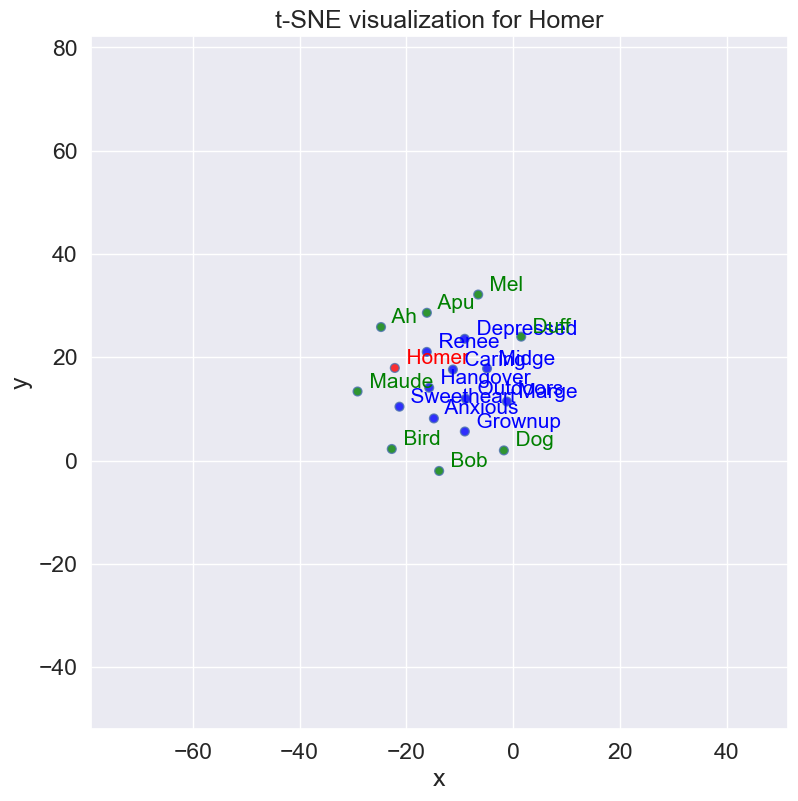

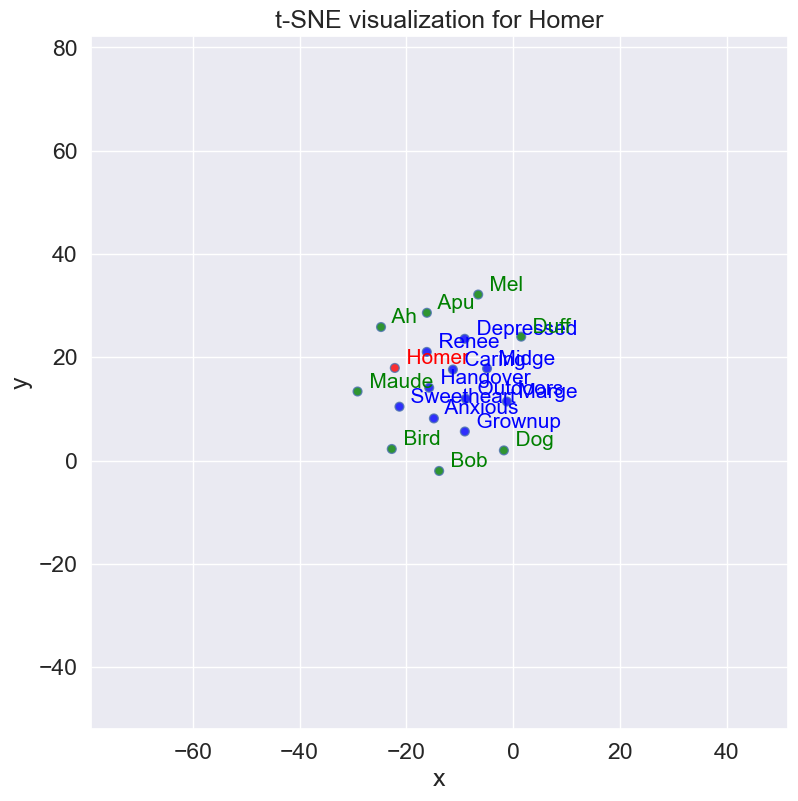

In [84]:
tsnescatterplot(w2v_model, 'homer', ['dog', 'bird', 'ah', 'maude', 'bob', 'mel', 'apu', 'duff'])

## 10 Most similar words vs. 10 Most dissimilar

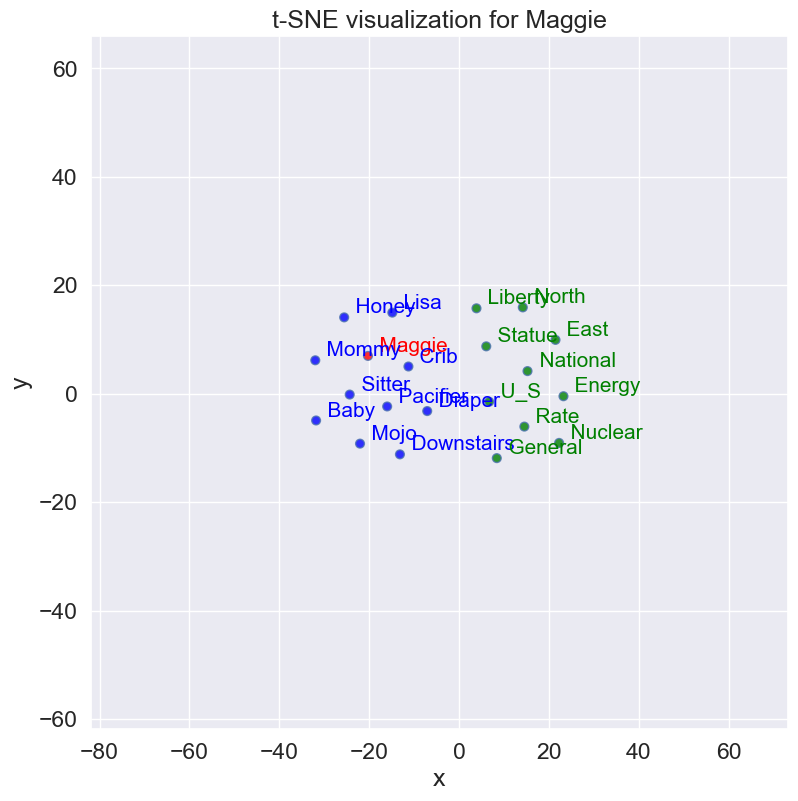

In [86]:
tsnescatterplot(w2v_model, 'maggie', [i[0] for i in w2v_model.wv.most_similar(negative=["maggie"])])